# Cell-Type-Aware Similarity: Building GEP Trees Across K Values

**Prerequisite:** Run `gsea_celltype_annotation.ipynb` first to generate NES CSVs.

**Problem:** Naive correlation of all GEPs at K with all GEPs at K+1 can conflate programs from different cell types, producing spurious cross-cell-type edges.

**Solution:** Choose one of two similarity metrics:
1. **`nes_spearman`** — Spearman correlation of NES profile vectors (GEP × cell type)
2. **`nes_kl_divergence`** — Similarity derived from symmetric KL divergence of cell-type probability distributions (mapped from KL ∈ [0, ∞) to similarity ∈ (0, 1] via exp(−λ · KL))

**Output:** An edge list defining the GEP tree across K values, plus visualizations.

In [1]:
import os
import glob
import re
import numpy as np
import pandas as pd
from scipy.stats import spearmanr
from scipy.special import rel_entr  # for KL divergence
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

## 1. Configuration

In [ ]:
# ──────────────────────────────────────────────────
# Paths
# ──────────────────────────────────────────────────
GSEA_DIR = "gsea_celltype_results"        # Directory with NES_k*.csv files
OUTPUT_DIR = "celltype_gated_correlation_results_spearman"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ──────────────────────────────────────────────────
# K range
# ──────────────────────────────────────────────────
K_MIN = 5
K_MAX = 15

# ──────────────────────────────────────────────────
# Similarity metric (pick ONE)
# ──────────────────────────────────────────────────
# "nes_kl_divergence"  — Symmetric KL divergence mapped to similarity via exp(-λ·KL)
# "nes_spearman"       — Spearman correlation of NES profile vectors
SIMILARITY_METRIC = "nes_spearman"

# ──────────────────────────────────────────────────
# KL divergence parameters (only used when SIMILARITY_METRIC == "nes_kl_divergence")
# ──────────────────────────────────────────────────
LAMBDA_KL = 0.5   # Controls steepness of the KL → similarity mapping:
                   #   exp(-λ·KL).  Larger λ = stricter (small KL differences already produce low similarity).
                   #   λ = 0.5 is a reasonable default
EPSILON = 1e-8     # Small constant to avoid log(0) in KL computation

# ──────────────────────────────────────────────────
# Edge selection
# ──────────────────────────────────────────────────
# For each child GEP at K+1, pick the best parent at K. A parent can have multiple children (splitting).
MIN_SIMILARITY = 0.3  # Minimum similarity to form an edge.
                       # For nes_spearman: Spearman rho threshold.
                       # For nes_kl_divergence: exp(-λ·KL) threshold --> converts the KL into a (0 to 1) range 

# ──────────────────────────────────────────────────
# Cell-type ambiguity detection
# ──────────────────────────────────────────────────
AMBIGUITY_THRESHOLD = 0.25  # If (1st_prob - 2nd_prob) / 1st_prob < this,
                             # label node as "Ambiguous/Mixed" instead of
                             # the top cell type.  Range [0, 1]:
                             #   0.0 = never ambiguous (always pick top)
                             #   1.0 = almost always ambiguous

print(f"Similarity metric: {SIMILARITY_METRIC}")
if SIMILARITY_METRIC == "nes_kl_divergence":
    print(f"  Lambda (KL mapping): {LAMBDA_KL}")
    print(f"  Epsilon: {EPSILON}")
print(f"Min similarity threshold: {MIN_SIMILARITY}")
print(f"Ambiguity threshold: {AMBIGUITY_THRESHOLD}")
print(f"K range: {K_MIN}–{K_MAX}")

Similarity metric: nes_spearman
Min similarity threshold: 0.3
Ambiguity threshold: 0.25
K range: 5–15


## 2. Load NES Scores

In [3]:
all_nes = {}   # k -> DataFrame (GEPs × cell types)
k_values = []

for f in sorted(glob.glob(os.path.join(GSEA_DIR, "NES_k*.csv"))):
    match = re.search(r'NES_k(\d+)\.csv', os.path.basename(f))
    if match:
        k = int(match.group(1))
        if K_MIN <= k <= K_MAX:
            df = pd.read_csv(f, index_col=0)
            all_nes[k] = df
            k_values.append(k)

k_values = sorted(k_values)
print(f"Loaded NES for {len(k_values)} K values: {k_values}")
for k in k_values:
    print(f"  K={k}: {all_nes[k].shape[0]} GEPs × {all_nes[k].shape[1]} cell types")

Loaded NES for 11 K values: [5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
  K=5: 5 GEPs × 17 cell types
  K=6: 6 GEPs × 17 cell types
  K=7: 7 GEPs × 17 cell types
  K=8: 8 GEPs × 17 cell types
  K=9: 9 GEPs × 17 cell types
  K=10: 10 GEPs × 17 cell types
  K=11: 11 GEPs × 17 cell types
  K=12: 12 GEPs × 17 cell types
  K=13: 13 GEPs × 17 cell types
  K=14: 14 GEPs × 17 cell types
  K=15: 15 GEPs × 17 cell types


## 3. Helper Functions

In [ ]:
def nes_to_distribution(nes_row, epsilon=EPSILON):
    """
    Convert a NES score vector into a probability distribution
    for KL divergence computation.
    Applies ReLU (only positive enrichments contribute), then normalizes.
    If no positive values exist, returns a uniform distribution.
    """
    vals = np.maximum(nes_row.values.astype(float), 0.0)
    if vals.sum() == 0:
        return np.ones(len(vals)) / len(vals)
    dist = vals / vals.sum()
    dist = dist + epsilon
    dist = dist / dist.sum()
    return dist


def assign_celltype(nes_row, epsilon=EPSILON, ambiguity_threshold=AMBIGUITY_THRESHOLD):
    """
    Assign a cell-type label to a GEP, or 'Ambiguous/Mixed' if the top two
    cell types are too close in the probability distribution.
    Uses the same ReLU-then-normalize distribution as nes_to_distribution().

    Parameters
    ----------
    nes_row : pd.Series
        NES scores indexed by cell type.
    epsilon : float
        Numerical stability constant (passed to distribution).
    ambiguity_threshold : float
        If (p_1st - p_2nd) / p_1st < this value, return 'Ambiguous/Mixed'.

    Returns
    -------
    str : assigned cell-type label (or 'Ambiguous/Mixed').
    """
    dist = nes_to_distribution(nes_row, epsilon)
    dist_series = pd.Series(dist, index=nes_row.index)
    ranked = dist_series.sort_values(ascending=False)

    top1_ct = ranked.index[0]
    top1_prob = ranked.iloc[0]

    if len(ranked) < 2 or top1_prob == 0:
        return top1_ct

    top2_prob = ranked.iloc[1]
    dominance = (top1_prob - top2_prob) / top1_prob   # 1 = fully dominant

    if dominance < ambiguity_threshold:
        return "Ambiguous/Mixed"
    return top1_ct


def symmetric_kl(p, q):
    """
    Symmetric KL divergence: 0.5 * (KL(P||Q) + KL(Q||P)).
    Returns 0 when P == Q, increases without bound as distributions diverge.
    """
    return 0.5 * (np.sum(rel_entr(p, q)) + np.sum(rel_entr(q, p)))


def compute_similarity(nes_parent, nes_child,
                       metric="nes_spearman",
                       lambda_kl=LAMBDA_KL, epsilon=EPSILON):
    """
    Compute similarity between a parent GEP and a child GEP using the
    chosen metric.

    Parameters
    ----------
    nes_parent, nes_child : pd.Series
        NES score vectors indexed by cell type.
    metric : str
        'nes_spearman' or 'nes_kl_divergence'.
    lambda_kl : float
        Steepness of KL → similarity mapping (only for nes_kl_divergence).
    epsilon : float
        Numerical stability constant (only for nes_kl_divergence).

    Returns
    -------
    dict with keys:
        'similarity' : float  — final similarity value
        'raw_value'  : float  — Spearman rho or raw KL divergence
        'parent_celltype' : str
        'child_celltype'  : str
        'celltype_match'  : bool
    """
    # Align cell types
    common_ct = nes_parent.index.intersection(nes_child.index)
    p_aligned = nes_parent[common_ct]
    c_aligned = nes_child[common_ct]

    parent_ct = assign_celltype(p_aligned)
    child_ct = assign_celltype(c_aligned)
    ct_match = (parent_ct == child_ct)

    if metric == "nes_spearman":
        if len(common_ct) < 3:
            sim = 0.0
            raw = 0.0
        else:
            rho, _ = spearmanr(p_aligned.values, c_aligned.values)
            rho = rho if not np.isnan(rho) else 0.0
            sim = rho
            raw = rho

    elif metric == "nes_kl_divergence":
        p_dist = nes_to_distribution(p_aligned, epsilon)
        c_dist = nes_to_distribution(c_aligned, epsilon)
        kl = symmetric_kl(p_dist, c_dist)
        sim = np.exp(-lambda_kl * kl)   # maps KL ∈ [0,∞) → sim ∈ (0, 1]
        raw = kl

    else:
        raise ValueError(f"Unknown metric: {metric}")

    return {
        'similarity': sim,
        'raw_value': raw,
        'parent_celltype': parent_ct,
        'child_celltype': child_ct,
        'celltype_match': ct_match
    }

## 4. Compute All Pairwise Similarities Across Consecutive K Values

In [5]:
# For each consecutive (K, K+1) pair, compute the full similarity matrix
# between all parent GEPs at K and all child GEPs at K+1.

all_sim_matrices = {}   # (k_parent, k_child) -> DataFrame
all_detail_records = [] # list of dicts for detailed inspection

for i in range(len(k_values) - 1):
    k_parent = k_values[i]
    k_child = k_values[i + 1]

    nes_p = all_nes[k_parent]
    nes_c = all_nes[k_child]

    sim_matrix = pd.DataFrame(
        index=nes_p.index,
        columns=nes_c.index,
        dtype=float
    )

    for parent_gep in nes_p.index:
        for child_gep in nes_c.index:
            result = compute_similarity(
                nes_parent=nes_p.loc[parent_gep],
                nes_child=nes_c.loc[child_gep],
                metric=SIMILARITY_METRIC,
                lambda_kl=LAMBDA_KL,
                epsilon=EPSILON
            )

            sim_matrix.loc[parent_gep, child_gep] = result['similarity']

            all_detail_records.append({
                'k_parent': k_parent,
                'k_child': k_child,
                'parent_gep': parent_gep,
                'child_gep': child_gep,
                'similarity': result['similarity'],
                'raw_value': result['raw_value'],
                'parent_celltype': result['parent_celltype'],
                'child_celltype': result['child_celltype'],
                'celltype_match': result['celltype_match']
            })

    all_sim_matrices[(k_parent, k_child)] = sim_matrix

    print(f"K={k_parent} → K={k_child}: "
          f"{sim_matrix.shape[0]} parents × {sim_matrix.shape[1]} children, "
          f"max similarity = {sim_matrix.values.max():.3f}")

details_df = pd.DataFrame(all_detail_records)
print(f"\nTotal pairwise comparisons: {len(details_df)}")

K=5 → K=6: 5 parents × 6 children, max similarity = 1.000
K=6 → K=7: 6 parents × 7 children, max similarity = 0.995
K=7 → K=8: 7 parents × 8 children, max similarity = 0.985
K=8 → K=9: 8 parents × 9 children, max similarity = 1.000
K=9 → K=10: 9 parents × 10 children, max similarity = 1.000
K=10 → K=11: 10 parents × 11 children, max similarity = 1.000
K=11 → K=12: 11 parents × 12 children, max similarity = 0.971
K=12 → K=13: 12 parents × 13 children, max similarity = 0.975
K=13 → K=14: 13 parents × 14 children, max similarity = 1.000
K=14 → K=15: 14 parents × 15 children, max similarity = 1.000

Total pairwise comparisons: 1080


## 5. Build the Edge List (Parent → Child Assignments)

**Strategy:** For each child GEP at K+1, assign the best parent at K (greedy best-match-per-child). A parent can have 0, 1, or many children (supporting splits). Children with no parent above `MIN_SIMILARITY` are flagged as "novel" (de novo emergence).

In [6]:
edges = []

for (k_parent, k_child), sim_matrix in sorted(all_sim_matrices.items()):
    for child_gep in sim_matrix.columns:
        best_parent = sim_matrix[child_gep].idxmax()
        best_sim = sim_matrix[child_gep].max()

        if best_sim >= MIN_SIMILARITY:
            parent_ct = assign_celltype(all_nes[k_parent].loc[best_parent])
            child_ct = assign_celltype(all_nes[k_child].loc[child_gep])

            edges.append({
                'k_parent': k_parent,
                'k_child': k_child,
                'parent_gep': best_parent,
                'child_gep': child_gep,
                'similarity': round(best_sim, 4),
                'parent_celltype': parent_ct,
                'child_celltype': child_ct,
                'celltype_match': parent_ct == child_ct
            })
        else:
            child_ct = assign_celltype(all_nes[k_child].loc[child_gep])
            edges.append({
                'k_parent': k_parent,
                'k_child': k_child,
                'parent_gep': None,
                'child_gep': child_gep,
                'similarity': round(best_sim, 4),
                'parent_celltype': None,
                'child_celltype': child_ct,
                'celltype_match': False
            })

edges_df = pd.DataFrame(edges)

n_connected = edges_df['parent_gep'].notna().sum()
n_novel = edges_df['parent_gep'].isna().sum()
n_ct_match = edges_df.loc[edges_df['parent_gep'].notna(), 'celltype_match'].sum()

print(f"Total edges: {len(edges_df)}")
print(f"  Connected (parent assigned): {n_connected}")
print(f"  Novel (no parent above threshold): {n_novel}")
print(f"  Cell-type-matching edges: {n_ct_match}/{n_connected} "
      f"({100*n_ct_match/max(n_connected,1):.1f}%)")

edges_path = os.path.join(OUTPUT_DIR, "gep_tree_edges.csv")
edges_df.to_csv(edges_path, index=False)
print(f"\nEdge list saved to: {edges_path}")
edges_df.head(10)

Total edges: 105
  Connected (parent assigned): 105
  Novel (no parent above threshold): 0
  Cell-type-matching edges: 89/105 (84.8%)

Edge list saved to: celltype_gated_correlation_results_spearman/gep_tree_edges.csv


,k_parent,k_child,parent_gep,child_gep,similarity,parent_celltype,child_celltype,celltype_match
0,5,6,1,1,0.9975,Ambiguous/Mixed,Ambiguous/Mixed,True
1,5,6,2,2,0.9973,Tumor/Epithelials,Tumor/Epithelials,True
2,5,6,3,3,0.9969,Tumor/Epithelials,Tumor/Epithelials,True
3,5,6,4,4,0.9975,Ambiguous/Mixed,Ambiguous/Mixed,True
4,5,6,5,5,1.0000,Ambiguous/Mixed,Ambiguous/Mixed,True
5,5,6,2,6,0.8346,Tumor/Epithelials,Ambiguous/Mixed,False
6,6,7,1,1,0.9951,Ambiguous/Mixed,Ambiguous/Mixed,True
7,6,7,2,2,0.9891,Tumor/Epithelials,Tumor/Epithelials,True
8,6,7,3,3,0.9448,Tumor/Epithelials,Tumor/Epithelials,True
9,6,7,4,4,0.8919,Ambiguous/Mixed,Fibroblasts/Stromal,False


## 6. Identify Splits and Merges

- **Split:** A parent at K maps to 2+ children at K+1
- **Merge:** A child at K+1 is the best match for 2+ parents at K (rare with best-match-per-child, but detectable)

In [7]:
connected_edges = edges_df[edges_df['parent_gep'].notna()].copy()

# Splits: parents with multiple children
splits = connected_edges.groupby(['k_parent', 'parent_gep']).agg(
    n_children=('child_gep', 'count'),
    children=('child_gep', list),
    child_celltypes=('child_celltype', list)
).reset_index()
splits = splits[splits['n_children'] > 1].sort_values('n_children', ascending=False)

print(f"Splitting events (parent with 2+ children):")
print(f"{'='*70}")
if len(splits) == 0:
    print("  None detected.")
else:
    for _, row in splits.iterrows():
        parent_ct = assign_celltype(all_nes[row['k_parent']].loc[row['parent_gep']])
        child_cts = row['child_celltypes']
        same_ct = all(ct == parent_ct for ct in child_cts)
        tag = "same cell type" if same_ct else "CROSS cell type"
        print(f"  K={row['k_parent']} {row['parent_gep']} ({parent_ct}) → "
              f"{row['n_children']} children: {row['children']} [{tag}]")
        for child, ct in zip(row['children'], child_cts):
            print(f"    └─ {child} ({ct})")

# Novel programs
novel = edges_df[edges_df['parent_gep'].isna()]
print(f"\nNovel programs (no parent above threshold):")
print(f"{'='*70}")
if len(novel) == 0:
    print("  None.")
else:
    for _, row in novel.iterrows():
        print(f"  K={row['k_child']} {row['child_gep']} ({row['child_celltype']}) "
              f"— best sim was {row['similarity']:.3f}")

Splitting events (parent with 2+ children):
  K=5 2 (Tumor/Epithelials) → 2 children: [2, 6] [CROSS cell type]
    └─ 2 (Tumor/Epithelials)
    └─ 6 (Ambiguous/Mixed)
  K=6 6 (Ambiguous/Mixed) → 2 children: [6, 7] [same cell type]
    └─ 6 (Ambiguous/Mixed)
    └─ 7 (Ambiguous/Mixed)
  K=7 6 (Ambiguous/Mixed) → 2 children: [4, 7] [same cell type]
    └─ 4 (Ambiguous/Mixed)
    └─ 7 (Ambiguous/Mixed)
  K=8 8 (Ambiguous/Mixed) → 2 children: [7, 9] [same cell type]
    └─ 7 (Ambiguous/Mixed)
    └─ 9 (Ambiguous/Mixed)
  K=9 4 (Ambiguous/Mixed) → 2 children: [4, 5] [CROSS cell type]
    └─ 4 (Ambiguous/Mixed)
    └─ 5 (Plasma_XBP1)
  K=9 9 (Ambiguous/Mixed) → 2 children: [7, 10] [CROSS cell type]
    └─ 7 (Tumor/Epithelials)
    └─ 10 (Ambiguous/Mixed)
  K=10 7 (Tumor/Epithelials) → 2 children: [7, 10] [CROSS cell type]
    └─ 7 (Tumor/Epithelials)
    └─ 10 (Ambiguous/Mixed)
  K=11 3 (Tumor/Epithelials) → 2 children: [7, 8] [CROSS cell type]
    └─ 7 (Ambiguous/Mixed)
    └─ 8 (Ambiguous/

## 7. Visualizations

### 7a. Heatmaps: Similarity Matrices per K→K+1 Transition

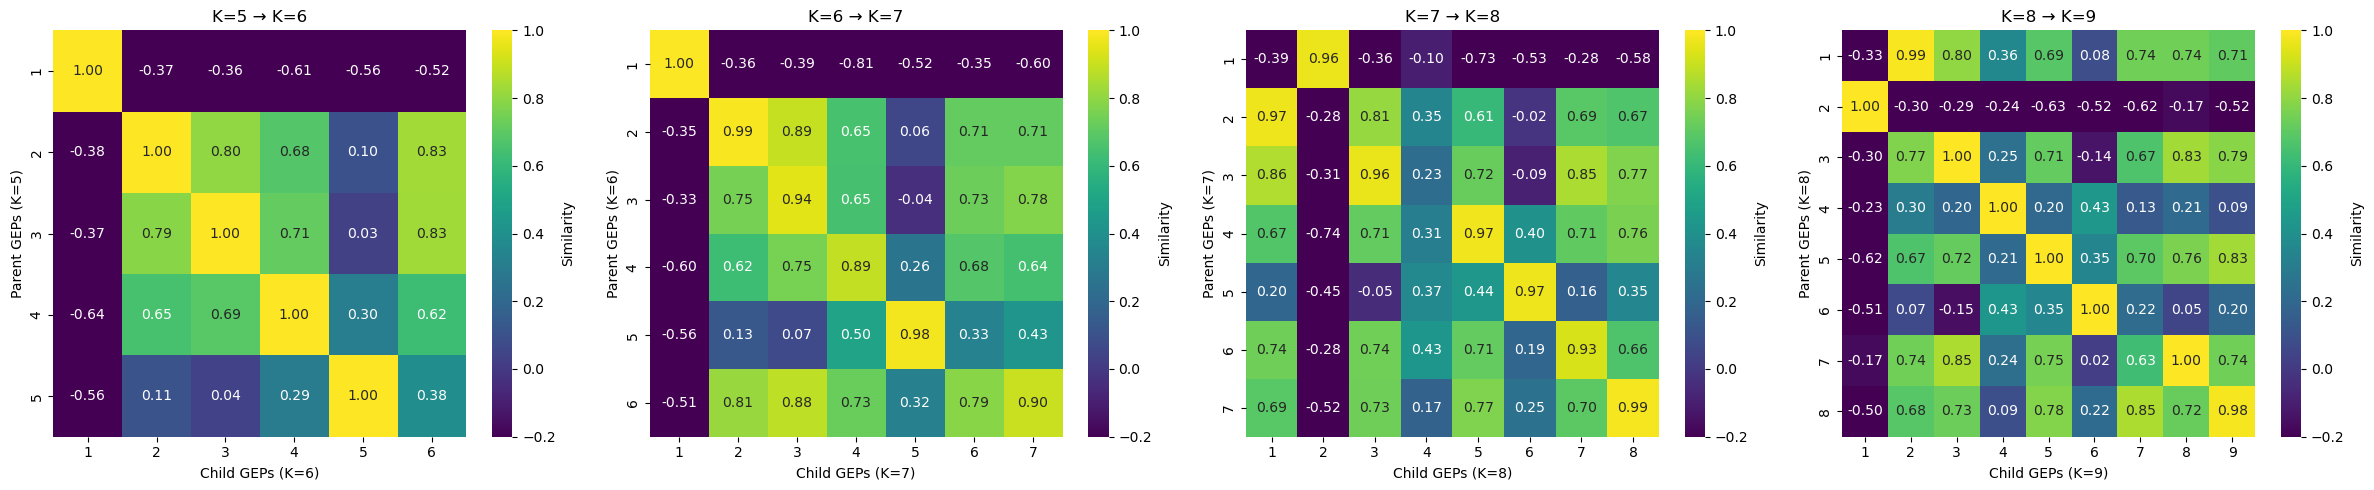

In [8]:
transitions_to_plot = list(all_sim_matrices.keys())[:4]

fig, axes = plt.subplots(1, len(transitions_to_plot),
                         figsize=(6 * len(transitions_to_plot), 5))
if len(transitions_to_plot) == 1:
    axes = [axes]

for ax, (k_p, k_c) in zip(axes, transitions_to_plot):
    sim = all_sim_matrices[(k_p, k_c)].astype(float)
    sns.heatmap(sim, cmap='viridis', annot=sim.shape[0] <= 12,
                fmt='.2f' if sim.shape[0] <= 12 else '',
                ax=ax, vmin=-0.2, vmax=1.0,
                cbar_kws={'label': 'Similarity'})
    ax.set_title(f'K={k_p} → K={k_c}', fontsize=12)
    ax.set_xlabel(f'Child GEPs (K={k_c})')
    ax.set_ylabel(f'Parent GEPs (K={k_p})')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "similarity_heatmaps.png"), dpi=150, bbox_inches='tight')
plt.show()

### 7b. GEP Tree Diagram

A layered graph showing GEPs at each K level connected by parent→child edges. Nodes are colored by their top cell type.

In [9]:
# Assign a color to each cell type
all_celltypes = set()
for k in k_values:
    for gep in all_nes[k].index:
        all_celltypes.add(assign_celltype(all_nes[k].loc[gep]))
all_celltypes = sorted(all_celltypes)

cmap = plt.cm.get_cmap('tab20', len(all_celltypes))
ct_colors = {ct: cmap(i) for i, ct in enumerate(all_celltypes)}

print(f"Cell types in tree: {len(all_celltypes)}")
for ct in all_celltypes:
    print(f"  {ct}")

Cell types in tree: 5
  Ambiguous/Mixed
  Endothelials
  Fibroblasts/Stromal
  Plasma_XBP1
  Tumor/Epithelials


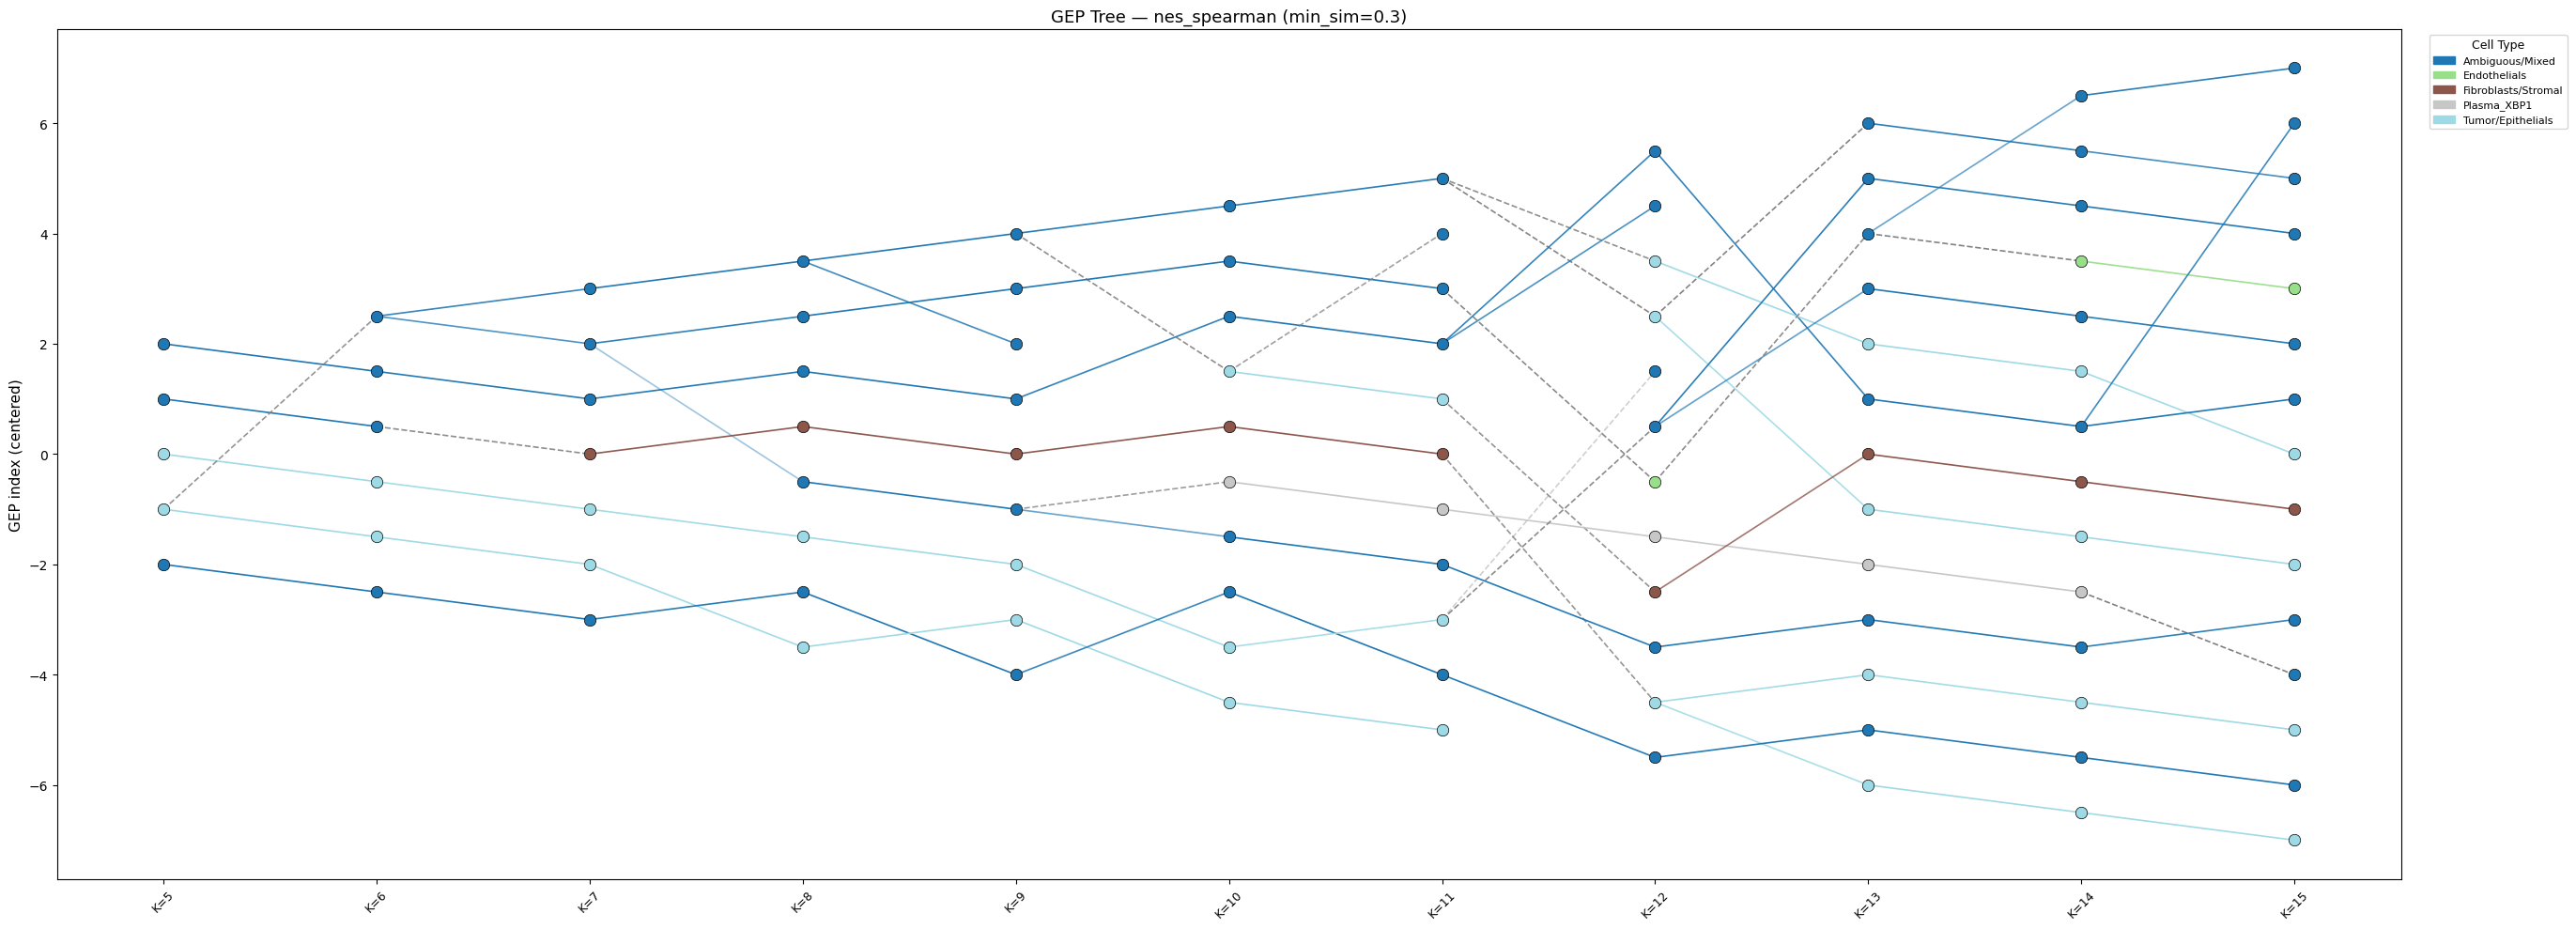

In [10]:
fig, ax = plt.subplots(figsize=(max(20, len(k_values) * 2.5), max(10, max(k_values) * 0.4)))

node_pos = {}
node_ct = {}

for xi, k in enumerate(k_values):
    n_geps = len(all_nes[k])
    for yi, gep in enumerate(all_nes[k].index):
        y = yi - (n_geps - 1) / 2
        node_pos[(k, gep)] = (xi, y)
        node_ct[(k, gep)] = assign_celltype(all_nes[k].loc[gep])

# Draw edges
connected = edges_df[edges_df['parent_gep'].notna()]
for _, row in connected.iterrows():
    p_key = (row['k_parent'], row['parent_gep'])
    c_key = (row['k_child'], row['child_gep'])
    if p_key in node_pos and c_key in node_pos:
        px, py = node_pos[p_key]
        cx, cy = node_pos[c_key]
        alpha = min(1.0, max(0.15, row['similarity']))
        color = 'gray' if not row['celltype_match'] else ct_colors.get(row['parent_celltype'], 'gray')
        ls = '-' if row['celltype_match'] else '--'
        ax.plot([px, cx], [py, cy], color=color, alpha=alpha, lw=1.2, ls=ls, zorder=1)

# Draw nodes
for (k, gep), (x, y) in node_pos.items():
    ct = node_ct[(k, gep)]
    color = ct_colors.get(ct, 'gray')
    ax.scatter(x, y, c=[color], s=80, edgecolors='black', linewidths=0.5, zorder=2)

ax.set_xticks(range(len(k_values)))
ax.set_xticklabels([f'K={k}' for k in k_values], fontsize=9, rotation=45)
ax.set_ylabel('GEP index (centered)', fontsize=11)
ax.set_title(f'GEP Tree — {SIMILARITY_METRIC} (min_sim={MIN_SIMILARITY})', fontsize=13)

patches = [mpatches.Patch(color=ct_colors[ct], label=ct) for ct in all_celltypes]
ax.legend(handles=patches, loc='upper left', bbox_to_anchor=(1.01, 1.0),
          fontsize=8, title='Cell Type', title_fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "gep_tree_diagram.png"), dpi=150, bbox_inches='tight')
plt.show()

### 7c. Cell Type Composition Across K Values

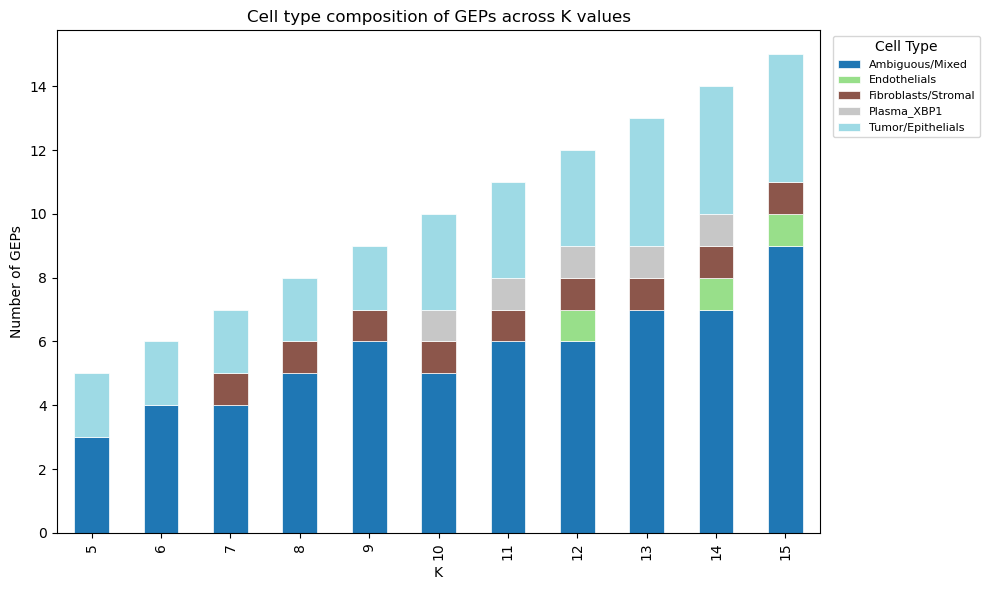

In [11]:
composition = []
for k in k_values:
    for gep in all_nes[k].index:
        ct = assign_celltype(all_nes[k].loc[gep])
        composition.append({'K': k, 'CellType': ct})

comp_df = pd.DataFrame(composition)
comp_pivot = comp_df.groupby(['K', 'CellType']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(max(10, len(k_values) * 0.6), 6))
comp_pivot.plot(kind='bar', stacked=True, ax=ax,
                color=[ct_colors.get(ct, 'gray') for ct in comp_pivot.columns],
                edgecolor='white', linewidth=0.5)
ax.set_xlabel('K')
ax.set_ylabel('Number of GEPs')
ax.set_title('Cell type composition of GEPs across K values')
ax.legend(bbox_to_anchor=(1.01, 1.0), fontsize=8, title='Cell Type')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "celltype_composition_by_k.png"), dpi=150, bbox_inches='tight')
plt.show()

## 8. Save Pairwise Results

In [12]:
details_path = os.path.join(OUTPUT_DIR, "pairwise_similarities.csv")
details_df.to_csv(details_path, index=False)
print(f"Saved detailed pairwise similarities: {details_path}")
print(f"Shape: {details_df.shape}")
details_df.head()

Saved detailed pairwise similarities: celltype_gated_correlation_results_spearman/pairwise_similarities.csv
Shape: (1080, 9)


,k_parent,k_child,parent_gep,child_gep,similarity,raw_value,parent_celltype,child_celltype,celltype_match
0,5,6,1,1,0.997546,0.997546,Ambiguous/Mixed,Ambiguous/Mixed,True
1,5,6,1,2,-0.368339,-0.368339,Ambiguous/Mixed,Tumor/Epithelials,False
2,5,6,1,3,-0.364498,-0.364498,Ambiguous/Mixed,Tumor/Epithelials,False
3,5,6,1,4,-0.612171,-0.612171,Ambiguous/Mixed,Ambiguous/Mixed,True
4,5,6,1,5,-0.559166,-0.559166,Ambiguous/Mixed,Ambiguous/Mixed,True


In [13]:
for (k_p, k_c), sim_mat in all_sim_matrices.items():
    path = os.path.join(OUTPUT_DIR, f"sim_matrix_k{k_p}_to_k{k_c}.csv")
    sim_mat.to_csv(path)

print(f"Saved {len(all_sim_matrices)} similarity matrices to {OUTPUT_DIR}/")

Saved 10 similarity matrices to celltype_gated_correlation_results_spearman/


## 9. Per-Transition Summary Table

In [14]:
transition_summary = []

for (k_p, k_c) in sorted(all_sim_matrices.keys()):
    subset = edges_df[(edges_df['k_parent'] == k_p) & (edges_df['k_child'] == k_c)]
    connected = subset[subset['parent_gep'].notna()]
    novel = subset[subset['parent_gep'].isna()]

    if len(connected) > 0:
        parent_counts = connected['parent_gep'].value_counts()
        n_splits = (parent_counts > 1).sum()
    else:
        n_splits = 0

    transition_summary.append({
        'transition': f'K={k_p}→{k_c}',
        'n_parents': len(all_nes[k_p]),
        'n_children': len(all_nes[k_c]),
        'n_edges': len(connected),
        'n_novel': len(novel),
        'n_splits': n_splits,
        'pct_same_ct': f"{100 * connected['celltype_match'].mean():.0f}%" if len(connected) > 0 else 'N/A',
        'mean_sim': f"{connected['similarity'].mean():.3f}" if len(connected) > 0 else 'N/A'
    })

tsummary_df = pd.DataFrame(transition_summary)
tsummary_df.to_csv(os.path.join(OUTPUT_DIR, "transition_summary.csv"), index=False)
print(tsummary_df.to_string(index=False))

transition  n_parents  n_children  n_edges  n_novel  n_splits pct_same_ct mean_sim
     K=5→6          5           6        6        0         1         83%    0.971
     K=6→7          6           7        7        0         1         86%    0.926
     K=7→8          7           8        8        0         1        100%    0.897
     K=8→9          8           9        9        0         1        100%    0.979
    K=9→10          9          10       10        0         2         80%    0.902
   K=10→11         10          11       11        0         1         91%    0.962
   K=11→12         11          12       12        0         3         42%    0.860
   K=12→13         12          13       13        0         3         85%    0.908
   K=13→14         13          14       14        0         1         93%    0.956
   K=14→15         14          15       15        0         1         93%    0.956


## 10. Metric Comparison: NES Spearman vs. NES KL Divergence

For a sample K → K+1 transition, compute **both** metrics for every parent–child pair and compare them side-by-side. This helps build intuition for where the two metrics agree (same-cell-type pairs) and where they diverge (cross-cell-type pairs where Spearman may still be moderate but KL-based similarity drops).

In [15]:
# Pick the first available consecutive K pair
k_sample_parent = k_values[0]
k_sample_child = k_values[1]

nes_p = all_nes[k_sample_parent]
nes_c = all_nes[k_sample_child]

comparison_rows = []

for parent_gep in nes_p.index:
    for child_gep in nes_c.index:
        # ── Spearman on raw NES vectors ──
        common_ct = nes_p.columns.intersection(nes_c.columns)
        p_vals = nes_p.loc[parent_gep, common_ct].values.astype(float)
        c_vals = nes_c.loc[child_gep, common_ct].values.astype(float)
        rho, _ = spearmanr(p_vals, c_vals)
        rho = rho if not np.isnan(rho) else 0.0

        # ── KL divergence on cell-type distributions ──
        p_dist = nes_to_distribution(nes_p.loc[parent_gep][common_ct], EPSILON)
        c_dist = nes_to_distribution(nes_c.loc[child_gep][common_ct], EPSILON)
        kl = symmetric_kl(p_dist, c_dist)
        kl_sim = np.exp(-LAMBDA_KL * kl)

        parent_ct = assign_celltype(nes_p.loc[parent_gep][common_ct])
        child_ct = assign_celltype(nes_c.loc[child_gep][common_ct])

        comparison_rows.append({
            'parent_gep': parent_gep,
            'child_gep': child_gep,
            'parent_celltype': parent_ct,
            'child_celltype': child_ct,
            'celltype_match': parent_ct == child_ct,
            'spearman_rho': round(rho, 4),
            'kl_divergence': round(kl, 4),
            'kl_similarity': round(kl_sim, 4),
        })

comp_df = pd.DataFrame(comparison_rows)

print(f"Comparing metrics for K={k_sample_parent} → K={k_sample_child}")
print(f"  {len(nes_p)} parents × {len(nes_c)} children = {len(comp_df)} pairs")
print(f"  Cell-type matching pairs: {comp_df['celltype_match'].sum()}")
print(f"  Cross-cell-type pairs:    {(~comp_df['celltype_match']).sum()}")
print()

# Summary stats split by cell-type match
for label, group in comp_df.groupby('celltype_match'):
    tag = "SAME cell type" if label else "CROSS cell type"
    print(f"  {tag} (n={len(group)}):")
    print(f"    Spearman rho   — mean={group['spearman_rho'].mean():.3f},  "
          f"median={group['spearman_rho'].median():.3f},  "
          f"range=[{group['spearman_rho'].min():.3f}, {group['spearman_rho'].max():.3f}]")
    print(f"    KL similarity  — mean={group['kl_similarity'].mean():.3f},  "
          f"median={group['kl_similarity'].median():.3f},  "
          f"range=[{group['kl_similarity'].min():.3f}, {group['kl_similarity'].max():.3f}]")
    print(f"    Raw KL div     — mean={group['kl_divergence'].mean():.3f},  "
          f"median={group['kl_divergence'].median():.3f}")
    print()

comp_df.to_csv(os.path.join(OUTPUT_DIR, "metric_comparison.csv"), index=False)
comp_df.head(10)

Comparing metrics for K=5 → K=6
  5 parents × 6 children = 30 pairs
  Cell-type matching pairs: 16
  Cross-cell-type pairs:    14

  CROSS cell type (n=14):
    Spearman rho   — mean=0.228,  median=0.102,  range=[-0.384, 0.835]
    KL similarity  — mean=0.143,  median=0.129,  range=[0.019, 0.341]
    Raw KL div     — mean=4.561,  median=4.149

  SAME cell type (n=16):
    Spearman rho   — mean=0.331,  median=0.503,  range=[-0.637, 1.000]
    KL similarity  — mean=0.666,  median=0.573,  range=[0.218, 1.000]
    Raw KL div     — mean=1.020,  median=1.112



,parent_gep,child_gep,parent_celltype,child_celltype,celltype_match,spearman_rho,kl_divergence,kl_similarity
0,1,1,Ambiguous/Mixed,Ambiguous/Mixed,True,0.9975,0.0000,1.0000
1,1,2,Ambiguous/Mixed,Tumor/Epithelials,False,-0.3683,6.1901,0.0453
2,1,3,Ambiguous/Mixed,Tumor/Epithelials,False,-0.3645,7.8910,0.0193
3,1,4,Ambiguous/Mixed,Ambiguous/Mixed,True,-0.6122,3.0410,0.2186
4,1,5,Ambiguous/Mixed,Ambiguous/Mixed,True,-0.5592,1.1104,0.5740
5,1,6,Ambiguous/Mixed,Ambiguous/Mixed,True,-0.5224,1.0613,0.5882
6,2,1,Tumor/Epithelials,Ambiguous/Mixed,False,-0.3839,6.2305,0.0444
7,2,2,Tumor/Epithelials,Tumor/Epithelials,True,0.9973,0.0002,0.9999
8,2,3,Tumor/Epithelials,Tumor/Epithelials,True,0.8011,1.3646,0.5054
9,2,4,Tumor/Epithelials,Ambiguous/Mixed,False,0.6810,2.1534,0.3407


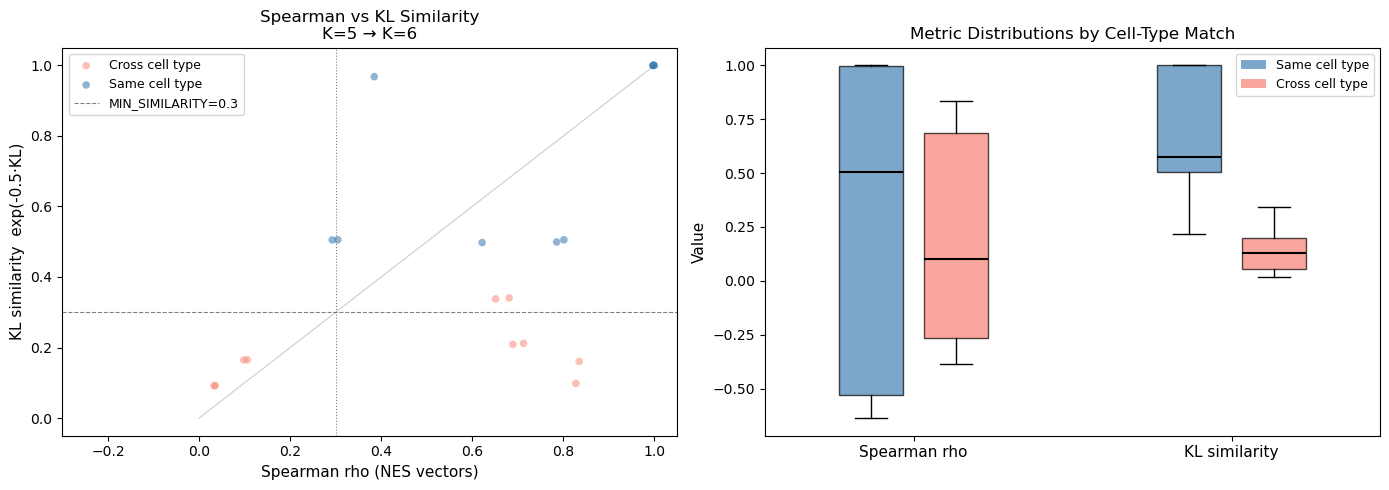

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: Spearman vs KL similarity scatter ──
ax = axes[0]
same = comp_df[comp_df['celltype_match']]
diff = comp_df[~comp_df['celltype_match']]

ax.scatter(diff['spearman_rho'], diff['kl_similarity'],
           alpha=0.5, s=30, c='salmon', label='Cross cell type', edgecolors='none')
ax.scatter(same['spearman_rho'], same['kl_similarity'],
           alpha=0.6, s=30, c='steelblue', label='Same cell type', edgecolors='none')

ax.axhline(y=MIN_SIMILARITY, color='gray', ls='--', lw=0.8, label=f'MIN_SIMILARITY={MIN_SIMILARITY}')
ax.axvline(x=MIN_SIMILARITY, color='gray', ls=':', lw=0.8)
ax.plot([0, 1], [0, 1], 'k-', alpha=0.2, lw=0.8)

ax.set_xlabel('Spearman rho (NES vectors)', fontsize=11)
ax.set_ylabel(f'KL similarity  exp(-{LAMBDA_KL}·KL)', fontsize=11)
ax.set_title(f'Spearman vs KL Similarity\nK={k_sample_parent} → K={k_sample_child}', fontsize=12)
ax.legend(fontsize=9)
ax.set_xlim(-0.3, 1.05)
ax.set_ylim(-0.05, 1.05)

# ── Right: distribution of each metric, split by match ──
ax = axes[1]
data_to_plot = [
    same['spearman_rho'].values,
    diff['spearman_rho'].values,
    same['kl_similarity'].values,
    diff['kl_similarity'].values,
]
positions = [0.8, 1.2, 2.3, 2.7]
colors = ['steelblue', 'salmon', 'steelblue', 'salmon']

bp = ax.boxplot(data_to_plot, positions=positions, widths=0.3, patch_artist=True,
                showfliers=False, medianprops=dict(color='black', lw=1.5))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_xticks([1.0, 2.5])
ax.set_xticklabels(['Spearman rho', 'KL similarity'], fontsize=11)
ax.set_ylabel('Value', fontsize=11)
ax.set_title('Metric Distributions by Cell-Type Match', fontsize=12)

# Manual legend
from matplotlib.patches import Patch
ax.legend(handles=[Patch(fc='steelblue', alpha=0.7, label='Same cell type'),
                   Patch(fc='salmon', alpha=0.7, label='Cross cell type')],
          fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "metric_comparison_plots.png"), dpi=150, bbox_inches='tight')
plt.show()

Key question: look at the upper-left quadrant of the scatter plot.
Points there have HIGH Spearman but LOW KL similarity — these are
cross-cell-type pairs with similarly shaped NES profiles but different
dominant cell types. KL catches these; Spearman does not.